In [1]:
import pandas as pd
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from glob import glob
import cv2
import tensorflow as tf
import subprocess
import os

In [2]:
print(tf.config.list_physical_devices('GPU'))


[]


In [3]:
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy('mixed_float16')

In [4]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("bhavikjikadara/dog-and-cat-classification-dataset")

# print("Path to dataset files:", path)

In [5]:
dataset_dir = '/Users/swagat98/Proj_1/datasets/cats_dogs'
dogs_train = '/Users/swagat98/Proj_1/datasets/cats_dogs/dogs_train'
dogs_test = '/Users/swagat98/Proj_1/datasets/cats_dogs/dogs_test'
cats_train = '/Users/swagat98/Proj_1/datasets/cats_dogs/cats_train'
cats_test = '/Users/swagat98/Proj_1/datasets/cats_dogs/cats_test'

cats_train = glob(f'{cats_train}/*')
dogs_train = glob(f'{dogs_train}/*')
cats_test = glob(f'{cats_test}/*')
dogs_test = glob(f'{dogs_test}/*')



In [6]:
len(cats_train)
len(cats_test)

3124

In [7]:

# num_images = len(cats)

catfile_trainlist = []
dogfile_trainlist = []
catfile_testlist = []
dogfile_testlist = []

for catfile in cats_train:

    catimg = cv2.imread(catfile)
    # cv2.imshow('webp image', resized_img)
    # cv2.waitKey(0)
    # cv2.destroyAllWindows()
    if catimg is not None:
        resized_catfile = cv2.resize(catimg, (200, 200), interpolation=cv2.INTER_AREA)
        catfile_trainlist.append(resized_catfile)
    else:
        print(f"Warning: Could not read image at {catfile}. Removing...")
        remove_cmd = f'rm {catfile}'
        subprocess.run(remove_cmd, shell=True)

for dogfile in dogs_train:

    dogimg = cv2.imread(dogfile)
    if dogimg is not None:
        resized_dogfile = cv2.resize(dogimg, (200,200), interpolation=cv2.INTER_AREA)
        dogfile_trainlist.append(resized_dogfile)
    else:
        print(f"Warning: Could not read image at {dogfile}. Removing...")
        remove_cmd = f'rm {dogfile}'
        subprocess.run(remove_cmd, shell=True)



for catfile in cats_test:

    catimg = cv2.imread(catfile)
    if catimg is not None:
        resized_catfile = cv2.resize(catimg, (200,200), interpolation=cv2.INTER_AREA)
        catfile_testlist.append(resized_catfile)
    else:
        print(f"Warning: Could not read image at {catfile}. Removing...")
        remove_cmd = f'rm {catfile}'
        subprocess.run(remove_cmd, shell=True)

for dogfile in dogs_test:
    dogimg = cv2.imread(dogfile)

    if dogimg is not None:
        resized_dogfile = cv2.resize(dogimg, (200,200), interpolation=cv2.INTER_AREA)
        dogfile_testlist.append(resized_dogfile)
    else:
        print(f"Warning: Could not read image at {dogfile}. Removing...")
        remove_cmd = f'rm {dogfile}'
        subprocess.run(remove_cmd, shell=True)




# print(len(catfile_trainlist))
# print(len(dogfile_trainlist))

Corrupt JPEG data: 214 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1153 extraneous bytes before marker 0xd9
Corrupt JPEG data: 99 extraneous bytes before marker 0xd9
Corrupt JPEG data: 65 extraneous bytes before marker 0xd9
Corrupt JPEG data: 226 extraneous bytes before marker 0xd9
Corrupt JPEG data: 162 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2230 extraneous bytes before marker 0xd9
Corrupt JPEG data: 128 extraneous bytes before marker 0xd9
Corrupt JPEG data: 239 extraneous bytes before marker 0xd9
Corrupt JPEG data: 254 extraneous bytes before marker 0xd9
Corrupt JPEG data: 399 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1403 extraneous bytes before marker 0xd9


In [8]:
# cv2.imshow('image', catfile_trainlist[0])

In [9]:
# import os
# os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # Force CPU

# # Then run your training

In [10]:
import tensorflow as tf

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


train_datagen = ImageDataGenerator(rescale=1./255.,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2)
test_datagen = ImageDataGenerator(
    rescale=1./255.)

train_generator = train_datagen.flow_from_directory(
  dataset_dir,
  target_size = (128,128),
  color_mode  = 'rgb',
  classes     = ['cats_train','dogs_train'],
  batch_size  = 256,
  class_mode  = 'binary',
  shuffle      = True,
  seed        = 42
)

test_generator = test_datagen.flow_from_directory(
  dataset_dir,
  target_size = (128,128),
  color_mode  = 'rgb',
  classes     = ['cats_test','dogs_test'],
  batch_size  = 256,
  class_mode  = 'binary',
  shuffle      = False,
  seed        = 42
)


Found 18749 images belonging to 2 classes.
Found 6248 images belonging to 2 classes.


In [12]:
# Get one batch of images and labels
batch_images, batch_labels = next(train_generator)

print(f"Batch shape: {batch_images.shape}")  # (batch_size, 200, 200, 3)
print(f"Labels shape: {batch_labels.shape}")  # (batch_size,)
print(f"Labels: {batch_labels}")

Batch shape: (256, 128, 128, 3)
Labels shape: (256,)
Labels: [0. 1. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 1. 1. 1. 0. 0. 1.
 1. 0. 1. 0. 0. 1. 0. 0. 1. 0. 1. 1. 1. 1. 0. 0. 1. 0. 1. 0. 1. 0. 1. 1.
 1. 0. 0. 1. 1. 1. 1. 1. 0. 1. 1. 0. 1. 1. 1. 1. 1. 0. 0. 0. 0. 1. 0. 0.
 0. 1. 1. 0. 0. 0. 0. 1. 1. 0. 0. 0. 1. 1. 0. 1. 1. 0. 1. 0. 1. 0. 1. 0.
 0. 0. 1. 0. 1. 0. 1. 0. 0. 1. 0. 0. 0. 1. 1. 0. 1. 0. 1. 0. 0. 0. 0. 0.
 0. 1. 1. 1. 0. 0. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0.
 0. 0. 0. 1. 1. 1. 0. 1. 1. 0. 0. 1. 0. 0. 1. 0. 0. 0. 1. 1. 1. 0. 0. 1.
 0. 0. 1. 0. 1. 1. 1. 1. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 1.
 1. 1. 1. 1. 0. 1. 0. 1. 1. 1. 1. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0.
 1. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0.
 0. 1. 1. 0. 0. 0. 0. 0. 1. 1. 0. 1. 1. 1. 0. 0.]


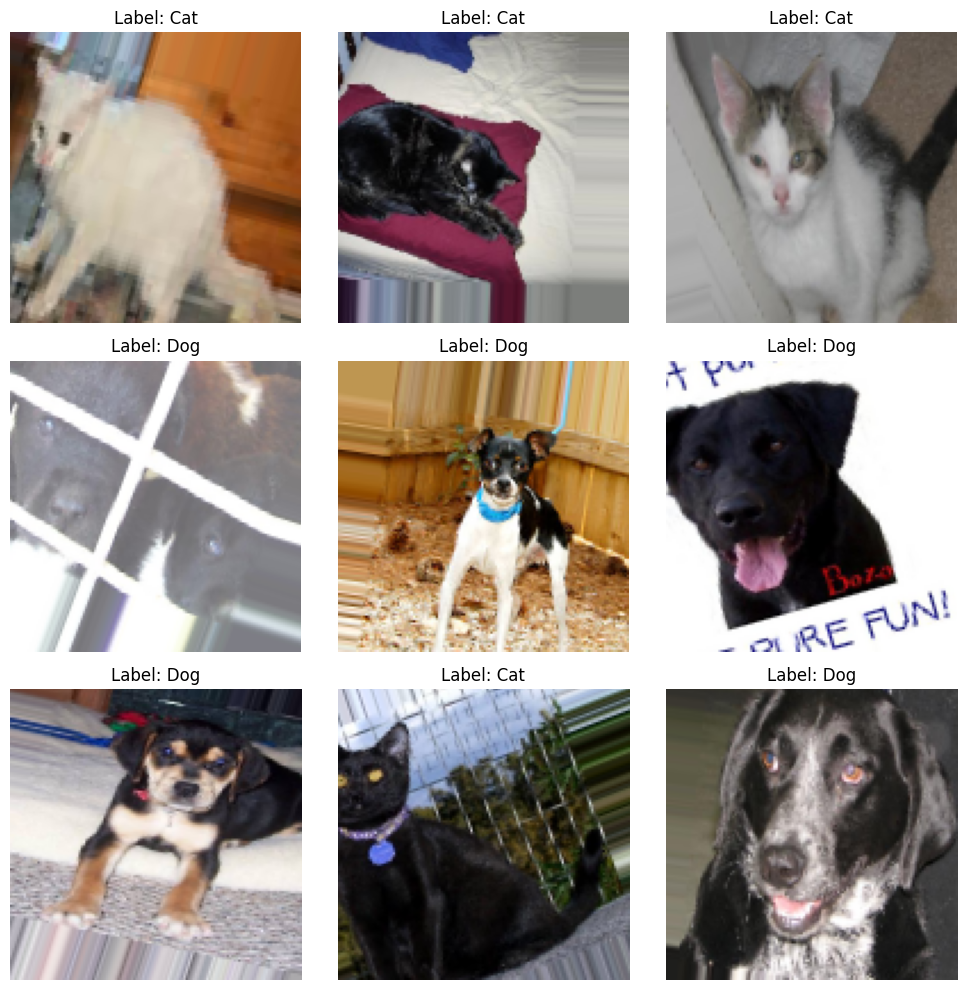

In [13]:
# Get a batch
batch_images, batch_labels = next(train_generator)

# Display first 9 images
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i in range(9):
    ax = axes[i//3, i%3]
    ax.imshow(batch_images[i])
    label = "Dog" if batch_labels[i] == 1 else "Cat"
    ax.set_title(f"Label: {label}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [14]:
# See how many batches per epoch
print(f"Total batches per epoch: {len(train_generator)}")

# See class indices mapping
print(f"Class indices: {train_generator.class_indices}")

# See total number of samples
print(f"Total samples: {train_generator.samples}")

# See number of classes
print(f"Number of classes: {train_generator.num_classes}")

Total batches per epoch: 74
Class indices: {'cats_train': 0, 'dogs_train': 1}
Total samples: 18749
Number of classes: 2


In [15]:
# dog_features = np.array(dogfile_trainlist, dtype='uint8')
# cat_features = np.array(catfile_trainlist, dtype='uint8')

# dog_features_test = np.array(dogfile_testlist, dtype='uint8')
# cat_features_test = np.array(catfile_testlist, dtype='uint8')
# # print(dog_features.shape)
# # print(cat_features.shape)

# x_train = np.concatenate([cat_features, dog_features], axis=0)
# x_test = np.concatenate([cat_features_test, dog_features_test], axis=0)

# print(x_train.shape)
# print(x_test.shape)



In [16]:
# # catslist_index = pd.DataFrame(['cats' for cats in range(0,50)])
# # dogslist_index = ['dogs' for dogs in range(0,50)]


# catslabel = np.zeros(len(catfile_trainlist))
# dogslabel = np.ones(len(dogfile_trainlist))

# catslabel_test = np.zeros(len(catfile_testlist))
# dogslabel_test = np.ones(len(dogfile_testlist))

# y_train = np.concatenate([catslabel, dogslabel])
# y_test = np.concatenate([catslabel_test, dogslabel_test])

# print(y_train.shape)
# y_train
# print(y_test.shape)
# # y_test




In [17]:
# x_train.shape, y_train.shape

In [18]:
# from sklearn.utils import shuffle

# x_train, y_train = shuffle(x_train, y_train)

# print(x_train.shape, y_train.shape)



In [19]:
# num_int = 35

# plt.imshow(x_train[num_int,:,:,:])
# print(y_train[num_int])

In [20]:
# # no need for train test split as it is already done. we can use for validation tho

# # from sklearn.model_selection import train_test_split

# # x_train, x_test, y_train, y_test = train_test_split(features, labels, random_state=42, test_size=0.2)

# print(x_train.shape)
# print(y_train.shape)
# print(x_test.shape)
# print(y_test.shape)

In [21]:
# x_train.shape
# x_train[0,:,:,:]

In [22]:
# # normalize

# x_train = x_train/255.
# x_test = x_test/255.


In [23]:
# y_test

In [24]:
# from tensorflow.python.client import device_lib
# print(device_lib.list_local_devices())

In [25]:
import tensorflow as tf

In [26]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(128,128,3)),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPool2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPool2D(2,2),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPool2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')

])


model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [27]:
model_history = model.fit(train_generator, epochs=20, validation_data=test_generator)

Epoch 1/20
 5/74 ━━━━━━━━━━━━━━━━━━━━ 4:32 4s/step - accuracy: 0.4879 - loss: 0.9910

KeyboardInterrupt: 

In [ ]:
test_generator.reset()
predictions = model.predict(test_generator)

# Convert probabilities to binary classes (0 or 1)
# 0.5 is the standard threshold
predicted_classes = (predictions > 0.5).astype(int).flatten()

# Get actual labels from the generator
true_classes = test_generator.classes

In [ ]:
import matplotlib.pyplot as plt

# Grab one batch of data from the generator
images, labels = next(test_generator)

plt.figure(figsize=(12, 12))

# Display the first 16 images of the batch
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(images[i])

    # Logic for labels
    true_label = "Dog" if labels[i+200] == 1 else "Cat"
    pred_label = "Dog" if predicted_classes[i+200] == 1 else "Cat"

    # Color code: Green if correct, Red if wrong
    color = 'green' if true_label == pred_label else 'red'

    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get the true labels from the generator
y_true = test_generator.classes

# 2. Predict and convert probabilities to binary (0 or 1)
# Ensure test_generator.shuffle was set to False!
test_generator.reset()
y_pred_probs = model.predict(test_generator)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# 3. Create the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 4. Plot using Seaborn for a nice visual
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cat', 'Dog'],
            yticklabels=['Cat', 'Dog'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# 5. Print the text-based report for Precision/Recall
print(classification_report(y_true, y_pred, target_names=['Cat', 'Dog']))

In [ ]:
# python# Plot training curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(model_history.history['accuracy'], label='Training')
plt.plot(model_history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(model_history.history['loss'], label='Training')
plt.plot(model_history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Reset generator to start from beginning
test_generator.reset()

# Get all predictions
predictions = model.predict(test_generator)
predicted_classes = (predictions > 0.5).astype(int).flatten()

# Get true labels
true_classes = test_generator.classes

# Get total number of samples
total_samples = len(true_classes)

# Randomly select 16 indices
random_indices = np.random.choice(total_samples, size=16, replace=False)

# Calculate which batch each index belongs to
batch_size = test_generator.batch_size
batches_needed = {}
for idx in random_indices:
    batch_num = idx // batch_size
    position_in_batch = idx % batch_size
    if batch_num not in batches_needed:
        batches_needed[batch_num] = []
    batches_needed[batch_num].append((idx, position_in_batch))

# Fetch images
selected_images = []
selected_true_labels = []
selected_pred_labels = []

test_generator.reset()
for batch_idx in range(max(batches_needed.keys()) + 1):
    batch_images, batch_labels = next(test_generator)
    if batch_idx in batches_needed:
        for original_idx, pos in batches_needed[batch_idx]:
            selected_images.append(batch_images[pos])
            selected_true_labels.append(true_classes[original_idx])
            selected_pred_labels.append(predicted_classes[original_idx])

# Plot
plt.figure(figsize=(12, 12))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(selected_images[i])

    true_label = "Dog" if selected_true_labels[i] == 1 else "Cat"
    pred_label = "Dog" if selected_pred_labels[i] == 1 else "Cat"

    color = 'green' if true_label == pred_label else 'red'

    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

#### 1 = cat 2 = dog

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b-', label='Training Acc')
    plt.plot(epochs, val_acc, 'r-', label='Validation Acc')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    plt.show()

plot_history(model_history)

In [ ]:
## Save model

model.save(f'/Users/swagat98/Proj_1/datasets/cats_dogs/cat_dog_classifiermodel.keras')

In [ ]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_binary)

sns.heatmap(cm, annot=True)